# Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report

# Import dataset

In [4]:
# Load dataset
df = pd.read_csv("IMB 621 VMW SERVER CASE TRAINING DATA 28 MAY 2017.csv")

# Replace 't'/'f' with 1/0
df = df.replace({'t': 1, 'f': 0})

# Drop non-numeric columns except the target
non_numeric = df.select_dtypes(include='object').columns
df = df.drop(columns=[col for col in non_numeric if col != 'train_period_workstation_purchase_flag'])

# Replace inf/-inf with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Define features and target
X = df.drop(columns=['train_period_workstation_purchase_flag'])
y = df['train_period_workstation_purchase_flag']

# Remove columns with all NaNs (causes mismatch after imputation)
X = X.dropna(axis=1, how='all')

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.3, random_state=42)


<ipython-input-4-1828796447>:2: DtypeWarning: Columns (444,445,446,447,450,451,452,453,455,456,457,458,461,463,464,465,466,474,475,476,477,480,481,482,483,485,486,487,488,491,493,494,495,496,783) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("IMB 621 VMW SERVER CASE TRAINING DATA 28 MAY 2017.csv")
<ipython-input-4-1828796447>:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'t': 1, 'f': 0})


# Get AUC score and ROC curve

* Find the value of area-under-curve (AUC) for the different techniques – random forest, boosting, and logistic regression.


Model AUC Scores:
Random Forest: AUC = 0.8868
Gradient Boosting: AUC = 0.9045
Logistic Regression: AUC = 0.5742


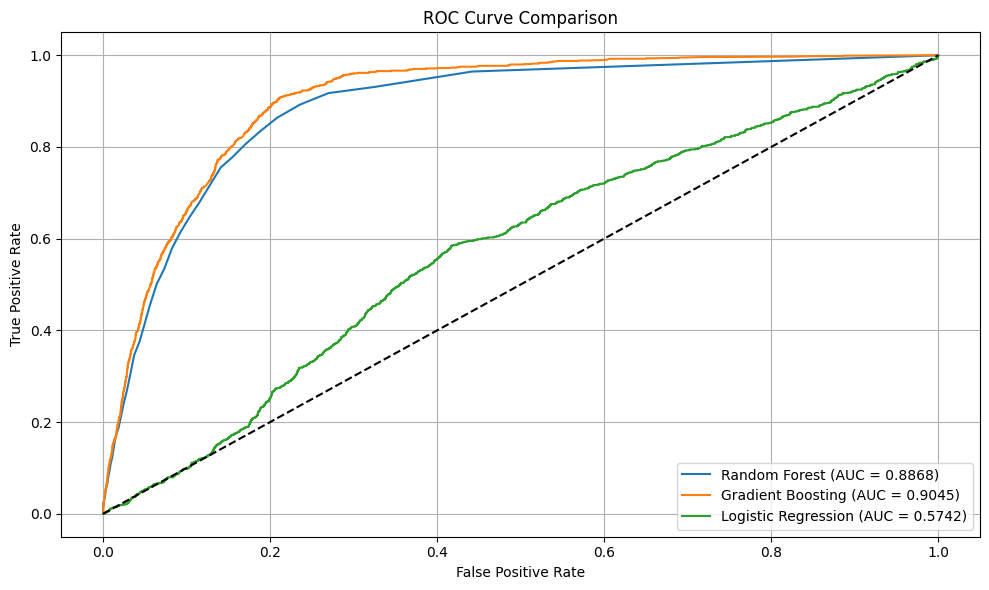

In [15]:
# Define models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear')
}

# Plot ROC curves and print AUCs
plt.figure(figsize=(10, 6))
print("Model AUC Scores:")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    print(f"{name}: AUC = {auc_score:.4f}")
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

# Plot formatting
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()

# List analysis

*   How do you define lift? Plot the lift curve for the different techniques.
*   Which technique gives the highest lift in the top 2 percentiles?
* Which technique gives the highest lift in the top decile?
* Which technique gives the best lift in the top quartile?


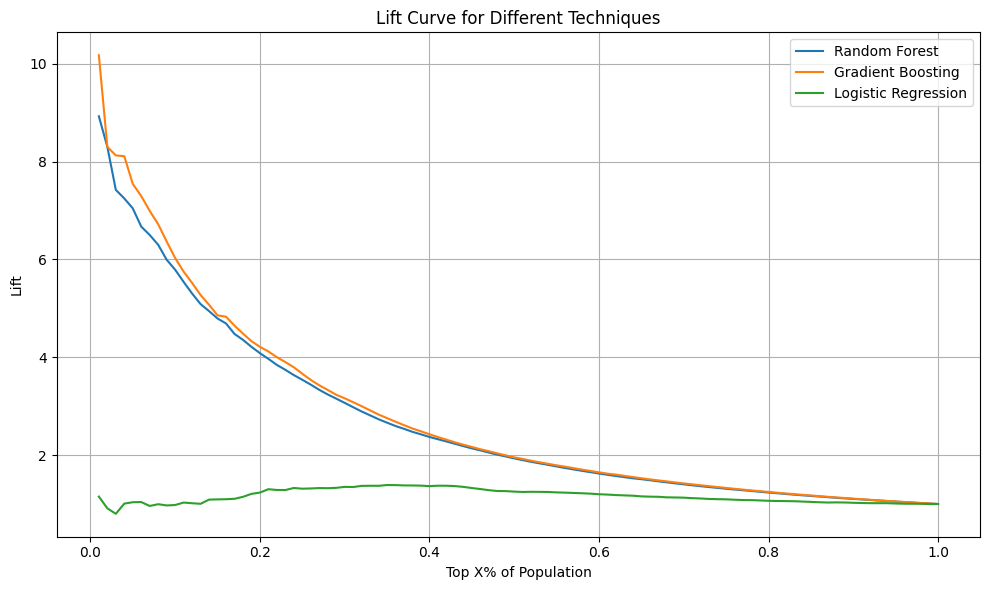


Lift Summary:
                       Top 2%   Top 10%   Top 25%
Random Forest        8.349328  5.786948  3.531670
Gradient Boosting    8.301344  6.026871  3.662188
Logistic Regression  0.911708  0.978887  1.312860


In [17]:

# Function to compute lift
def compute_lift(y_true, y_scores, percentiles=[0.02, 0.10, 0.25]):
    df = pd.DataFrame({'y_true': y_true, 'score': y_scores})
    df = df.sort_values('score', ascending=False).reset_index(drop=True)
    baseline = df['y_true'].mean()
    lifts = {}
    for p in percentiles:
        top_n = int(len(df) * p)
        top_df = df.iloc[:top_n]
        lifts[f"Top {int(p * 100)}%"] = top_df['y_true'].mean() / baseline
    return lifts

# Lift curve plot
plt.figure(figsize=(10, 6))
percentile_bins = np.linspace(0.01, 1.0, 100)
lift_summary = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_scores = model.predict_proba(X_test)[:, 1]
    y_base = y_test.reset_index(drop=True)
    lift_curve = []

    for p in percentile_bins:
        n = int(len(y_scores) * p)
        top_idx = np.argsort(y_scores)[::-1][:n]
        lift = y_base.iloc[top_idx].mean() / y_base.mean()
        lift_curve.append(lift)

    plt.plot(percentile_bins, lift_curve, label=name)
    lift_summary[name] = compute_lift(y_base, y_scores)

plt.xlabel("Top X% of Population")
plt.ylabel("Lift")
plt.title("Lift Curve for Different Techniques")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Show lift values for top 2%, 10%, and 25%
lift_df = pd.DataFrame(lift_summary).T
print("\nLift Summary:")
print(lift_df)


# Clustering and Classification
* How could clustering be combined with classification for this problem?


In [18]:
# Standardize for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
X_imputed['cluster'] = kmeans.fit_predict(X_scaled)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.3, random_state=42)

# Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_clf.fit(X_train, y_train)
y_pred_prob = gb_clf.predict_proba(X_test)[:, 1]

# AUC score
auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC with Clustering + Gradient Boosting: {auc:.4f}")


<ipython-input-18-1142920463>:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'t': 1, 'f': 0})


AUC with Clustering + Gradient Boosting: 0.9050


# Logistic Regression Questions:
* What value of regularization parameter leads to the best results for penalized logistic regression?
* How many features have non-zero coefficients when the penalization parameter alpha is set to 0?
* What is the answer when the value is set to 1?
* One more way to compare regularized vs. normal logistic regression is to look at the values of the coefficients. Can you compare the values at each decile for a normal and regularized logistic regression?


In [ ]:
# Impute and scale
X = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X), columns=X.columns)
X = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)

# Select top 100 features
selector = SelectKBest(score_func=f_classif, k=100)
X_selected = selector.fit_transform(X, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=42)

# Try multiple C values for L1 Logistic Regression
C_values = [0.01, 0.1, 1, 10]
best_auc = 0
best_c = None
auc_results = []

for c in C_values:
    model = LogisticRegression(penalty='l1', solver='liblinear', C=c, max_iter=300)
    model.fit(X_train, y_train)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_prob)
    print(f"C={c}: AUC={auc:.4f}")
    if auc > best_auc:
        best_auc = auc
        best_c = c

print(f"\nBest C value based on AUC: {best_c} (AUC = {best_auc:.4f})")


<ipython-input-6-4065792160>:11: DtypeWarning: Columns (444,445,446,447,450,451,452,453,455,456,457,458,461,463,464,465,466,474,475,476,477,480,481,482,483,485,486,487,488,491,493,494,495,496,783) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("IMB 621 VMW SERVER CASE TRAINING DATA 28 MAY 2017.csv")
<ipython-input-6-4065792160>:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'t': 1, 'f': 0})


C=0.01: AUC=0.8720
C=0.1: AUC=0.8727
C=1: AUC=0.8730
C=10: AUC=0.8729


In [5]:
# Feature and target
X = df.drop(columns=['train_period_workstation_purchase_flag'])
y = df['train_period_workstation_purchase_flag']

# Drop rows where target is NaN
mask = ~y.isna()
X = X[mask]
y = y[mask]

# Impute and scale
X = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X), columns=X.columns)
X = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)

# Select top 100 features
selector = SelectKBest(score_func=f_classif, k=100)
X_selected = selector.fit_transform(X, y)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=42)

# Logistic Regression with no regularization (α = 0)
lr_none = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
lr_none.fit(X_train, y_train)
non_zero_none = np.sum(lr_none.coef_[0] != 0)

# Logistic Regression with L1 penalty (α = 1 → C = 1)
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=1000)
lr_l1.fit(X_train, y_train)
non_zero_l1 = np.sum(lr_l1.coef_[0] != 0)

print("Non-zero coefficients with no regularization (α = 0):", non_zero_none)
print("Non-zero coefficients with L1 regularization (α = 1):", non_zero_l1)


<ipython-input-5-805067917>:10: DtypeWarning: Columns (444,445,446,447,450,451,452,453,455,456,457,458,461,463,464,465,466,474,475,476,477,480,481,482,483,485,486,487,488,491,493,494,495,496) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("IMB 621 VMW SERVER CASE TRAINING DATA 28 MAY 2017.csv")
<ipython-input-5-805067917>:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'t': 1, 'f': 0})
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  1   8  10  11  14  16  17  18  19  21  22  23  24  26  28  29  55  58
  59  60  61  62  65  67  69  70  71  72  73  76  77  78  81  82  87  89
  90  96  97  98  99 100 103 104 105 106 107 108 1

Non-zero coefficients with no regularization (α = 0): 100
Non-zero coefficients with L1 regularization (α = 1): 48


In [6]:
# Train no-penalty logistic regression
lr_none = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
lr_none.fit(X_train, y_train)
coef_none = np.abs(lr_none.coef_[0])

# Train L1-penalized logistic regression
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=1000)
lr_l1.fit(X_train, y_train)
coef_l1 = np.abs(lr_l1.coef_[0])

# Function to compute decile statistics
def get_deciles(coef_array):
    sorted_abs = np.sort(coef_array)
    return np.percentile(sorted_abs, [10 * i for i in range(1, 11)])

# Get decile values
deciles_none = get_deciles(coef_none)
deciles_l1 = get_deciles(coef_l1)

# Build and print DataFrame
decile_df = pd.DataFrame({
    'Decile (%)': [f'{i*10}-{(i+1)*10}%' for i in range(10)],
    'No Regularization': deciles_none,
    'L1 Regularized': deciles_l1
})

print(decile_df)


<ipython-input-6-3810632325>:10: DtypeWarning: Columns (444,445,446,447,450,451,452,453,455,456,457,458,461,463,464,465,466,474,475,476,477,480,481,482,483,485,486,487,488,491,493,494,495,496,783) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("IMB 621 VMW SERVER CASE TRAINING DATA 28 MAY 2017.csv")
<ipython-input-6-3810632325>:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'t': 1, 'f': 0})
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  1   8  10  11  14  17  18  19  21  22  23  24  26  28  29  55  58  59
  60  61  62  65  67  69  70  71  72  73  77  78  81  82  87  89  97  98
  99 100 103 104 105 106 107 108 111 114 115

  Decile (%)  No Regularization  L1 Regularized
0      0-10%           0.007618        0.000000
1     10-20%           0.013696        0.000027
2     20-30%           0.017631        0.007291
3     30-40%           0.027152        0.014207
4     40-50%           0.041036        0.027657
5     50-60%           0.052005        0.048416
6     60-70%           0.064672        0.064985
7     70-80%           0.096213        0.113998
8     80-90%           0.161173        0.198256
9    90-100%           1.350060        1.347678


# Class Imbalance
* What other methods can be used to handle imbalanced datasets such as this one?


In [7]:
# Load dataset
df = pd.read_csv("IMB 621 VMW SERVER CASE TRAINING DATA 28 MAY 2017.csv")

# Count and percentage distribution of target classes
class_distribution = df['train_period_workstation_purchase_flag'].value_counts(dropna=False)
class_percentages = df['train_period_workstation_purchase_flag'].value_counts(normalize=True, dropna=False) * 100

# Combine into a summary table
imbalance_summary = pd.DataFrame({
    'Count': class_distribution,
    'Percentage': class_percentages.round(2)
})

print("Target Variable Class Distribution:")
print(imbalance_summary)


<ipython-input-7-2849483211>:4: DtypeWarning: Columns (444,445,446,447,450,451,452,453,455,456,457,458,461,463,464,465,466,474,475,476,477,480,481,482,483,485,486,487,488,491,493,494,495,496,783) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("IMB 621 VMW SERVER CASE TRAINING DATA 28 MAY 2017.csv")


Target Variable Class Distribution:
                                        Count  Percentage
train_period_workstation_purchase_flag                   
0                                       96500        96.5
1                                        3500         3.5


In [8]:


# Assume X, y already defined
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Logistic Regression with class_weight
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression with class_weight='balanced'")
print(classification_report(y_test, y_pred_lr))


Logistic Regression with class_weight='balanced'
              precision    recall  f1-score   support

           0       0.99      0.81      0.89     28950
           1       0.14      0.83      0.23      1050

    accuracy                           0.81     30000
   macro avg       0.56      0.82      0.56     30000
weighted avg       0.96      0.81      0.87     30000



In [15]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv("IMB 621 VMW SERVER CASE TRAINING DATA 28 MAY 2017.csv")

# Replace 't'/'f' with 1/0
df.replace({'t': 1, 'f': 0}, inplace=True)

# Drop non-numeric columns except target
non_numeric_cols = df.select_dtypes(include='object').columns
df = df.drop(columns=[col for col in non_numeric_cols if col != 'train_period_workstation_purchase_flag'])

# Drop rows where target is NaN
df = df[df['train_period_workstation_purchase_flag'].notna()]

# Replace inf/-inf with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Define features and target
X = df.drop(columns=['train_period_workstation_purchase_flag'])
y = df['train_period_workstation_purchase_flag']

X = SimpleImputer(strategy='median').fit_transform(X)
X = StandardScaler().fit_transform(X)

# Select top 100 features
X_selected = SelectKBest(score_func=f_classif, k=100).fit_transform(X, y)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, stratify=y, test_size=0.3, random_state=42)

# SMOTE
smote = SMOTE(k_neighbors=3, random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

# Train
model = GradientBoostingClassifier(random_state=42)
model.fit(X_smote, y_smote)

# Evaluate
y_pred = model.predict(X_test)
print("Gradient Boosting with SMOTE (Top 100 Features, Cleaned)")
print(classification_report(y_test, y_pred))


<ipython-input-15-1809623791>:12: DtypeWarning: Columns (444,445,446,447,450,451,452,453,455,456,457,458,461,463,464,465,466,474,475,476,477,480,481,482,483,485,486,487,488,491,493,494,495,496,783) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("IMB 621 VMW SERVER CASE TRAINING DATA 28 MAY 2017.csv")
<ipython-input-15-1809623791>:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'t': 1, 'f': 0}, inplace=True)
/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['days_bw_draas_launch_and_purch' 'days_bw_prodX_launch_and_purch'
 'days_bw_prodP_launch_and_purch' 'days_bw_prodS_launch_and_purch'
 'days_bw_prodU_launch_and_purch' 

Gradient Boosting with SMOTE (Top 100 Features, Cleaned)
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     28950
           1       0.20      0.37      0.26      1050

    accuracy                           0.93     30000
   macro avg       0.59      0.66      0.61     30000
weighted avg       0.95      0.93      0.94     30000



In [16]:
from imblearn.under_sampling import RandomUnderSampler

# Undersample majority class
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train, y_train)

# Train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_under, y_under)
y_pred_rf = rf.predict(X_test)

print("Random Forest with Random Undersampling")
print(classification_report(y_test, y_pred_rf))


Random Forest with Random Undersampling
              precision    recall  f1-score   support

           0       0.99      0.79      0.88     28950
           1       0.13      0.86      0.23      1050

    accuracy                           0.80     30000
   macro avg       0.56      0.83      0.56     30000
weighted avg       0.96      0.80      0.86     30000



# Handle Imbalance and Classify (Top 100 Features + SMOTE + Gradient Boosting)

In [19]:
pip install imblearn

<ipython-input-20-2538905811>:13: DtypeWarning: Columns (444,445,446,447,450,451,452,453,455,456,457,458,461,463,464,465,466,474,475,476,477,480,481,482,483,485,486,487,488,491,493,494,495,496,783) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("IMB 621 VMW SERVER CASE TRAINING DATA 28 MAY 2017.csv")
<ipython-input-20-2538905811>:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'t': 1, 'f': 0}, inplace=True)
/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['days_bw_draas_launch_and_purch' 'days_bw_prodX_launch_and_purch'
 'days_bw_prodP_launch_and_purch' 'days_bw_prodS_launch_and_purch'
 'days_bw_prodU_launch_and_purch' 

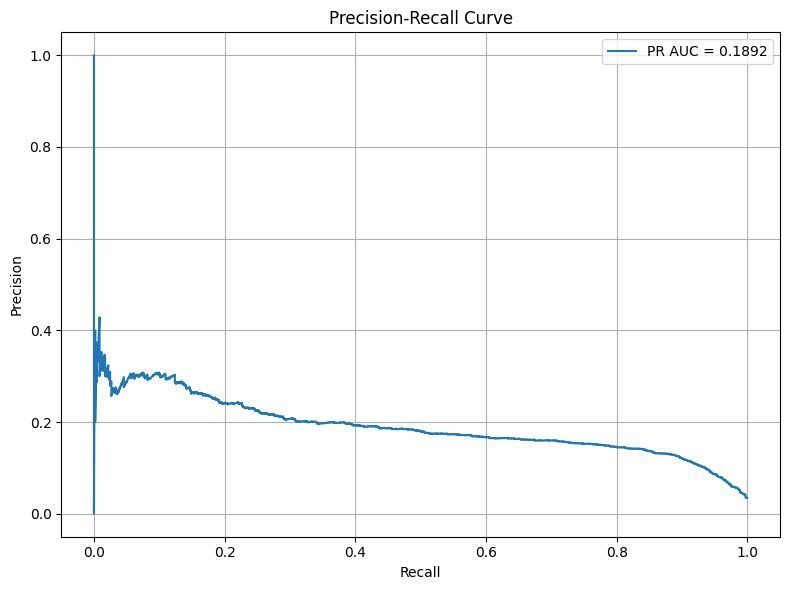

ROC AUC Score: 0.8836
PR AUC Score: 0.1892
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     28950
           1       0.20      0.37      0.26      1050

    accuracy                           0.93     30000
   macro avg       0.59      0.66      0.61     30000
weighted avg       0.95      0.93      0.94     30000



In [20]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# 1. Load and clean data
df = pd.read_csv("IMB 621 VMW SERVER CASE TRAINING DATA 28 MAY 2017.csv")
df.replace({'t': 1, 'f': 0}, inplace=True)
non_numeric_cols = df.select_dtypes(include='object').columns
df.drop(columns=[col for col in non_numeric_cols if col != 'train_period_workstation_purchase_flag'], inplace=True)
df = df[df['train_period_workstation_purchase_flag'].notna()]
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Feature matrix and target
X = df.drop(columns=['train_period_workstation_purchase_flag'])
y = df['train_period_workstation_purchase_flag']

# 3. Impute + Scale
X = SimpleImputer(strategy='median').fit_transform(X)
X = StandardScaler().fit_transform(X)

# Remove constant columns (avoids divide-by-zero error)
X = pd.DataFrame(X)
X = X.loc[:, X.std() > 0].values

# 4. Select top 100 features
X_selected = SelectKBest(score_func=f_classif, k=min(100, X.shape[1])).fit_transform(X, y)

# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, stratify=y, test_size=0.3, random_state=42)

# 6. SMOTE
smote = SMOTE(k_neighbors=3, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# 7. Train Gradient Boosting
model = GradientBoostingClassifier(random_state=42)
model.fit(X_resampled, y_resampled)

# 8. Predict + Evaluate
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_prob)
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)

# 9. Plot PR Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.4f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print metrics
print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"PR AUC Score: {pr_auc:.4f}")
print(classification_report(y_test, y_pred))


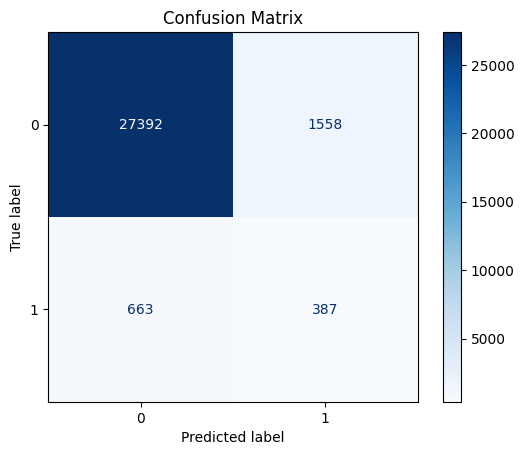

In [21]:
# Plot Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


### Still the precision is very low - trying the fine tuning

In [22]:
from sklearn.metrics import f1_score, precision_score

# Search for best threshold for F1
best_f1 = 0
best_threshold = 0.5

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []
precision_scores = []

for t in thresholds:
    y_pred_thresh = (y_pred_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)
    f1_scores.append(f1)
    precision_scores.append(precision)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Best F1-score: {best_f1:.4f} at threshold = {best_threshold:.2f}")


Best F1-score: 0.2662 at threshold = 0.45


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


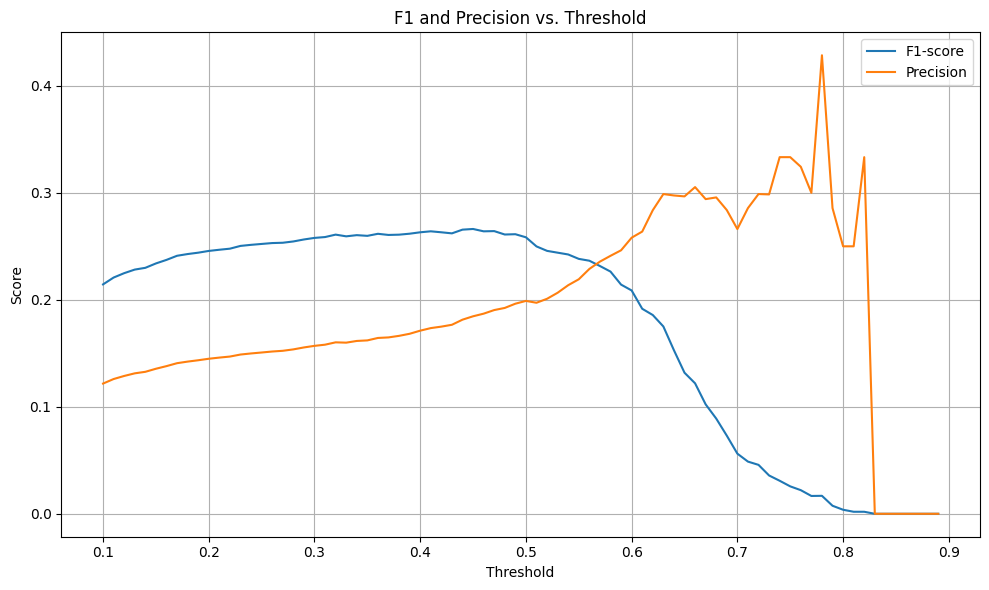

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, label='F1-score')
plt.plot(thresholds, precision_scores, label='Precision')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("F1 and Precision vs. Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [24]:
y_pred_optimized = (y_pred_prob >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_optimized))


              precision    recall  f1-score   support

           0       0.98      0.92      0.95     28950
           1       0.18      0.48      0.27      1050

    accuracy                           0.91     30000
   macro avg       0.58      0.70      0.61     30000
weighted avg       0.95      0.91      0.93     30000

